In [1]:
import pandas as pd
from pathlib import Path


from hcc_multimodal.baselines.transforms import (
    CLINICAL_X_COLUMNS,
    DataType,
    build_preprocessor,
)
from hcc_multimodal.baselines.evaluation import (
    run_cv_experiment,
    plot_pca_variance,
    plot_cv_results,
    plot_experiment_comparison,
)
from hcc_multimodal.baselines.config import PARAM_GRIDS


In [2]:
ROOT = Path().resolve().parents[1]


clinical_data = pd.read_csv(
    ROOT
    / "data"
    / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

radiomics_data = pd.read_csv(
    ROOT / "data" / "Radiomics" / "radiomic_cluster.csv"
).dropna(how="all")

rna_data = pd.read_csv(
    ROOT / "data" / "RNA_seq" / "Matrix_output_radiology_only.csv"
).dropna(how="all")

In [3]:
rna_data.head()

,ENSEMBL Gene ID,Gene Symbol,39,31,66,33,132,23,124,38,...,72,80,176,65,115,28,71,21,130,5
0,ENSG00000000003,TSPAN6,0,0,150,139,0,299,0,874,...,58,0,6215,0,0,137,0,0,0,0
1,ENSG00000000005,TNMD,0,0,0,0,0,42,0,844,...,30,1,1,0,0,0,0,17,0,0
2,ENSG00000000419,DPM1,0,0,153,0,0,133,0,1837,...,124,0,4411,0,0,204,0,0,0,0
3,ENSG00000000457,SCYL3,0,0,0,0,0,143,32,1887,...,131,42,2384,0,0,179,0,25,0,64
4,ENSG00000000460,C1orf112,0,0,0,0,37,262,0,1105,...,119,49,1485,0,0,88,0,0,0,0


In [4]:
columns = rna_data["Gene Symbol"]
rna_data = rna_data.T.iloc[2:, :]
rna_data.columns = columns.values

# Drop columns with NaN gene symbols and deduplicate gene names
rna_data = rna_data.loc[:, ~pd.isnull(rna_data.columns)]
rna_data = rna_data.loc[:, ~rna_data.columns.duplicated()]

# Convert expression values to numeric, make SID an integer column
rna_data = rna_data.apply(pd.to_numeric, errors="coerce")
rna_data.index = rna_data.index.astype(int)
rna_data = rna_data.rename_axis("SID").reset_index()

print(f"RNA data shape (patients × genes): {rna_data.shape}")
rna_data.head()

RNA data shape (patients × genes): (60, 50987)


,SID,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC134980.5,AL691520.1,AC139491.7,AC021097.2,AL590381.1,AC003043.2,AC135068.11,AL356417.3,AC104389.6,AP000646.1
0,39,0,0,0,0,0,0,245,0,0,...,0,0,0,0,0,0,0,0,0,0
1,31,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,66,150,0,153,0,0,0,828,63,0,...,0,0,0,0,0,0,0,0,0,0
3,33,139,0,0,0,0,0,3206,0,224,...,0,0,0,0,0,1,0,3,0,0
4,132,0,0,0,0,37,2,985,0,236,...,0,0,0,0,0,1,0,0,0,0


In [5]:
# RNA feature columns (all continuous)
rna_cols = [c for c in rna_data.columns if c != "SID"]
rna_x_columns = {col: DataType.CONTINUOUS for col in rna_cols}

# Combined RNA + clinical column spec
rna_clin_x_columns = {**CLINICAL_X_COLUMNS, **rna_x_columns}

# Death label from radiomics CSV
radiomic_death = radiomics_data[["SID", "death"]].copy()

# Dataset overlap summary
sid_rna = set(rna_data["SID"])
sid_clinical = set(clinical_data["SID"])
sid_radiomic = set(radiomics_data["SID"])
print(f"RNA patients              : {len(sid_rna)}")
print(f"RNA ∩ clinical            : {len(sid_rna & sid_clinical)}")
print(f"RNA ∩ radiomic (death)    : {len(sid_rna & sid_radiomic)}")
print(f"RNA ∩ clinical ∩ radiomic : {len(sid_rna & sid_clinical & sid_radiomic)}")

RNA patients              : 60
RNA ∩ clinical            : 60
RNA ∩ radiomic (death)    : 60
RNA ∩ clinical ∩ radiomic : 60


## Without grid search

Experiment 1 dataset size: 60


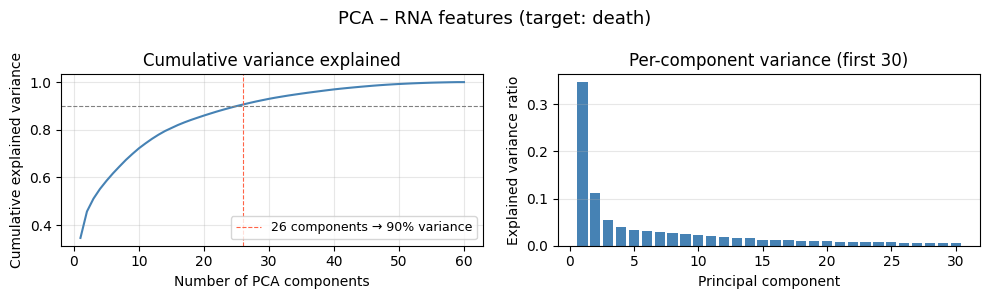

Components to reach 90% variance: 26 / 50986
[RNA → death]  n=60  positives=24  features=50986


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


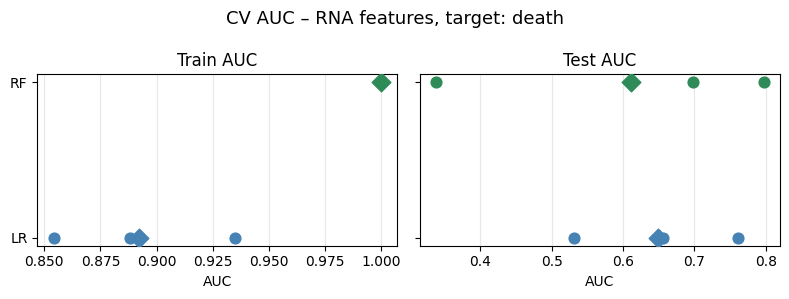

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA → death,LR,0.649,0.094,0.617,0.062
1,RNA → death,RF,0.611,0.197,0.600,0.082


In [6]:
# === Experiment 1: RNA features only, target = death (from radiomics CSV) ===
rna_rad = rna_data.merge(radiomic_death, on="SID", how="inner")
print(f"Experiment 1 dataset size: {len(rna_rad)}")

X_exp1 = rna_rad[rna_cols].reset_index(drop=True)
y_exp1 = rna_rad["death"].reset_index(drop=True)

X_pre1 = build_preprocessor(rna_x_columns).fit_transform(X_exp1[~y_exp1.isna()])
plot_pca_variance(X_pre1, title="PCA – RNA features (target: death)")

cv_results1, fold_df1 = run_cv_experiment(
    X_exp1, y_exp1, rna_x_columns, label="RNA → death"
)
plot_cv_results(fold_df1, title="CV AUC – RNA features, target: death")
cv_results1

Experiment 2 dataset size: 60


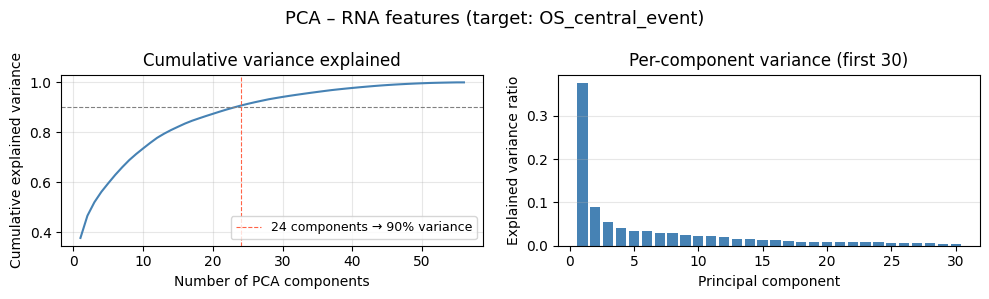

Components to reach 90% variance: 24 / 50986
[RNA → OS_central_event]  n=56  positives=21  features=50986


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


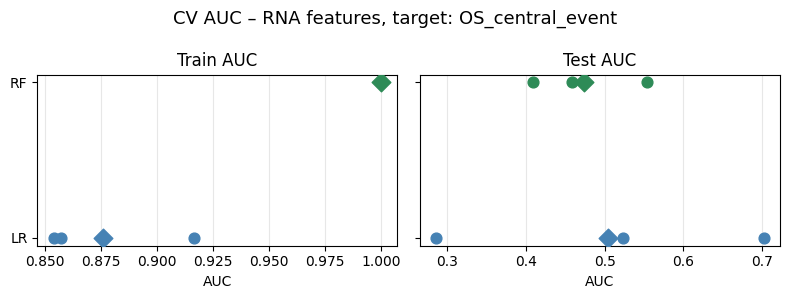

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA → OS_central_event,LR,0.504,0.171,0.551,0.114
1,RNA → OS_central_event,RF,0.474,0.060,0.552,0.079


In [7]:
# === Experiment 2: RNA features only, target = OS_central_event (from clinical) ===
rna_clin = rna_data.merge(
    clinical_data[["SID", "OS_central_event"]], on="SID", how="inner"
)
print(f"Experiment 2 dataset size: {len(rna_clin)}")

X_exp2 = rna_clin[rna_cols].reset_index(drop=True)
y_exp2 = rna_clin["OS_central_event"].reset_index(drop=True)

X_pre2 = build_preprocessor(rna_x_columns).fit_transform(X_exp2[~y_exp2.isna()])
plot_pca_variance(X_pre2, title="PCA – RNA features (target: OS_central_event)")

cv_results2, fold_df2 = run_cv_experiment(
    X_exp2, y_exp2, rna_x_columns, label="RNA → OS_central_event"
)
plot_cv_results(fold_df2, title="CV AUC – RNA features, target: OS_central_event")
cv_results2

Experiment 3 dataset size: 60


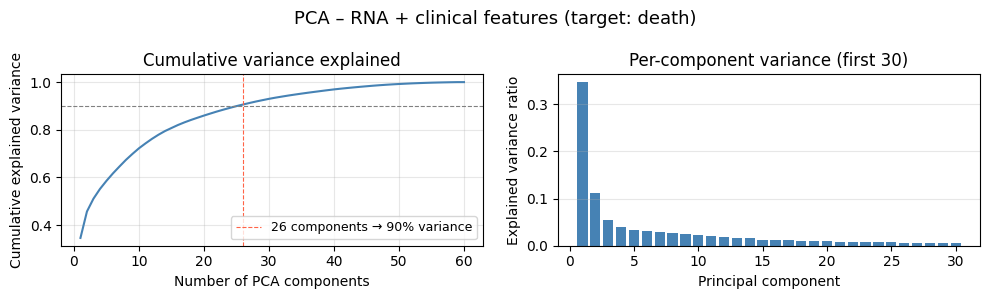

Components to reach 90% variance: 26 / 51012
[RNA+Clinical → death]  n=60  positives=24  features=50997


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


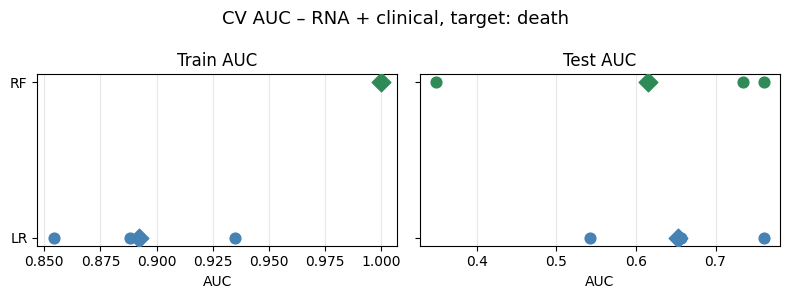

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA+Clinical → death,LR,0.653,0.089,0.617,0.062
1,RNA+Clinical → death,RF,0.615,0.188,0.567,0.062


In [8]:
# === Experiment 3: RNA + clinical features, target = death ===
rna_clin_rad = rna_data.merge(radiomic_death, on="SID", how="inner").merge(
    clinical_data, on="SID", how="inner"
)
print(f"Experiment 3 dataset size: {len(rna_clin_rad)}")

X_exp3 = rna_clin_rad[list(rna_clin_x_columns.keys())].reset_index(drop=True)
y_exp3 = rna_clin_rad["death"].reset_index(drop=True)

X_pre3 = build_preprocessor(rna_clin_x_columns).fit_transform(X_exp3[~y_exp3.isna()])
plot_pca_variance(X_pre3, title="PCA – RNA + clinical features (target: death)")

cv_results3, fold_df3 = run_cv_experiment(
    X_exp3, y_exp3, rna_clin_x_columns, label="RNA+Clinical → death"
)
plot_cv_results(fold_df3, title="CV AUC – RNA + clinical, target: death")
cv_results3

Experiment 4 dataset size: 60


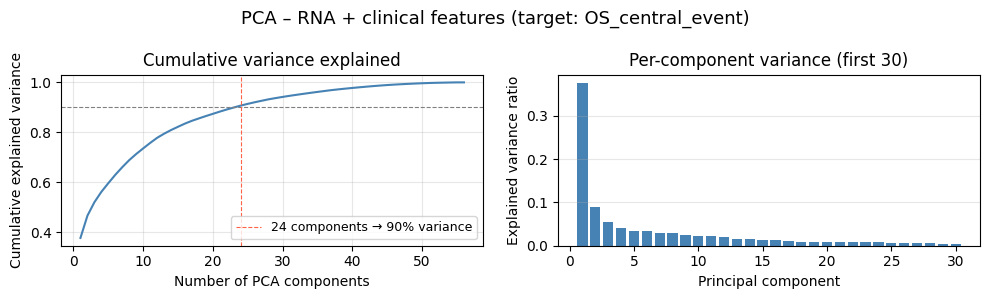

Components to reach 90% variance: 24 / 51012
[RNA+Clinical → OS_central_event]  n=56  positives=21  features=50997


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


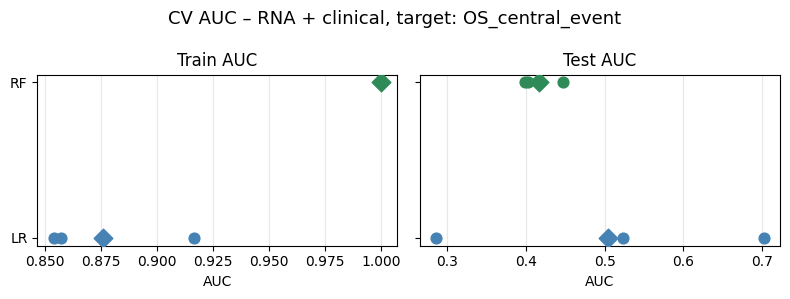

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA+Clinical → OS_central_event,LR,0.504,0.171,0.551,0.114
1,RNA+Clinical → OS_central_event,RF,0.416,0.022,0.534,0.063


In [9]:
# === Experiment 4: RNA + clinical features, target = OS_central_event ===
rna_clin_full = rna_data.merge(clinical_data, on="SID", how="inner")
print(f"Experiment 4 dataset size: {len(rna_clin_full)}")

X_exp4 = rna_clin_full[list(rna_clin_x_columns.keys())].reset_index(drop=True)
y_exp4 = rna_clin_full["OS_central_event"].reset_index(drop=True)

X_pre4 = build_preprocessor(rna_clin_x_columns).fit_transform(X_exp4[~y_exp4.isna()])
plot_pca_variance(
    X_pre4, title="PCA – RNA + clinical features (target: OS_central_event)"
)

cv_results4, fold_df4 = run_cv_experiment(
    X_exp4, y_exp4, rna_clin_x_columns, label="RNA+Clinical → OS_central_event"
)
plot_cv_results(fold_df4, title="CV AUC – RNA + clinical, target: OS_central_event")
cv_results4

                     experiment model  AUC mean  AUC std  Accuracy mean  Accuracy std
                    RNA → death    LR     0.649    0.094          0.617         0.062
                    RNA → death    RF     0.611    0.197          0.600         0.082
         RNA → OS_central_event    LR     0.504    0.171          0.551         0.114
         RNA → OS_central_event    RF     0.474    0.060          0.552         0.079
           RNA+Clinical → death    LR     0.653    0.089          0.617         0.062
           RNA+Clinical → death    RF     0.615    0.188          0.567         0.062
RNA+Clinical → OS_central_event    LR     0.504    0.171          0.551         0.114
RNA+Clinical → OS_central_event    RF     0.416    0.022          0.534         0.063


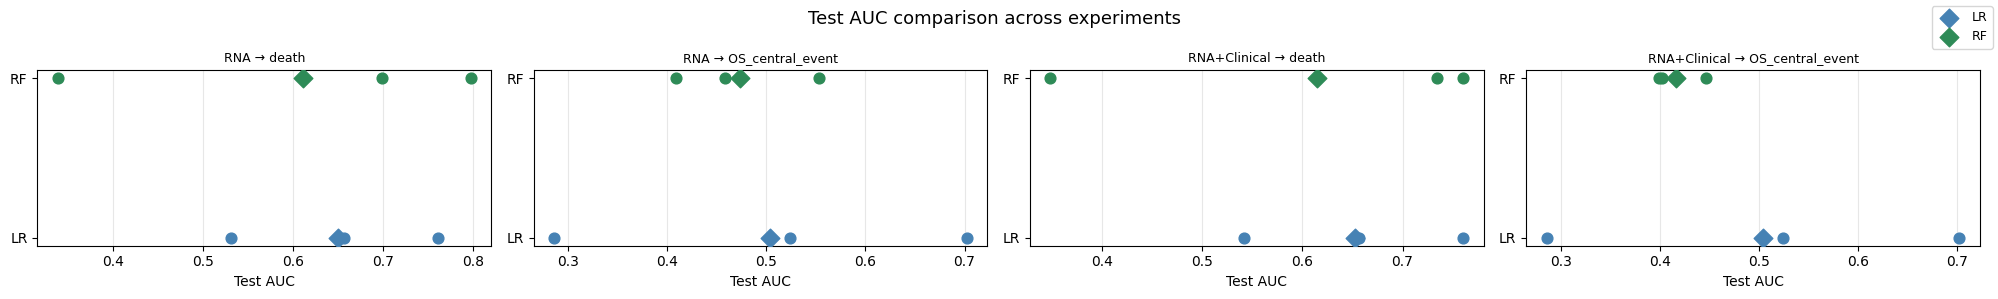

In [10]:
# === Combined comparison across all four experiments ===
all_cv = pd.concat(
    [cv_results1, cv_results2, cv_results3, cv_results4], ignore_index=True
)
all_folds = pd.concat([fold_df1, fold_df2, fold_df3, fold_df4], ignore_index=True)

print(all_cv.to_string(index=False))
plot_experiment_comparison(all_folds)

## With grid search

Experiment 1 dataset size: 60


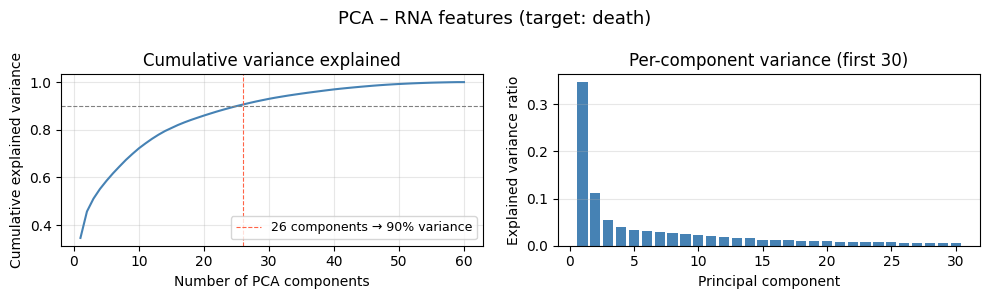

Components to reach 90% variance: 26 / 50986
[RNA → death]  n=60  positives=24  features=50986


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

model  fold                             best_params
   LR     1             {'C': 1.0, 'l1_ratio': 0.5}
   LR     2            {'C': 10.0, 'l1_ratio': 0.5}
   LR     3            {'C': 10.0, 'l1_ratio': 0.5}
   RF     1 {'max_depth': 3, 'min_samples_leaf': 1}
   RF     2 {'max_depth': 5, 'min_samples_leaf': 1}
   RF     3 {'max_depth': 3, 'min_samples_leaf': 5}


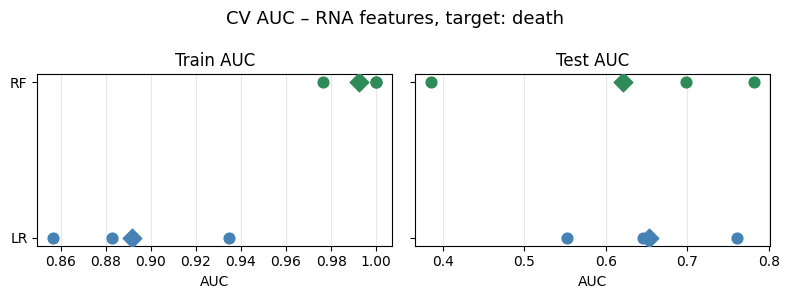

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA → death,LR,0.653,0.085,0.617,0.062
1,RNA → death,RF,0.622,0.170,0.567,0.085


In [11]:
# === Experiment 1: RNA features only, target = death (from radiomics CSV) ===
rna_rad = rna_data.merge(radiomic_death, on="SID", how="inner")
print(f"Experiment 1 dataset size: {len(rna_rad)}")

X_exp1 = rna_rad[rna_cols].reset_index(drop=True)
y_exp1 = rna_rad["death"].reset_index(drop=True)

X_pre1 = build_preprocessor(rna_x_columns).fit_transform(X_exp1[~y_exp1.isna()])
plot_pca_variance(X_pre1, title="PCA – RNA features (target: death)")

cv_results1, fold_df1 = run_cv_experiment(
    X_exp1,
    y_exp1,
    rna_x_columns,
    label="RNA → death",
    param_grids=PARAM_GRIDS,
)
print(fold_df1[["model", "fold", "best_params"]].to_string(index=False))
plot_cv_results(fold_df1, title="CV AUC – RNA features, target: death")
cv_results1

Experiment 2 dataset size: 60


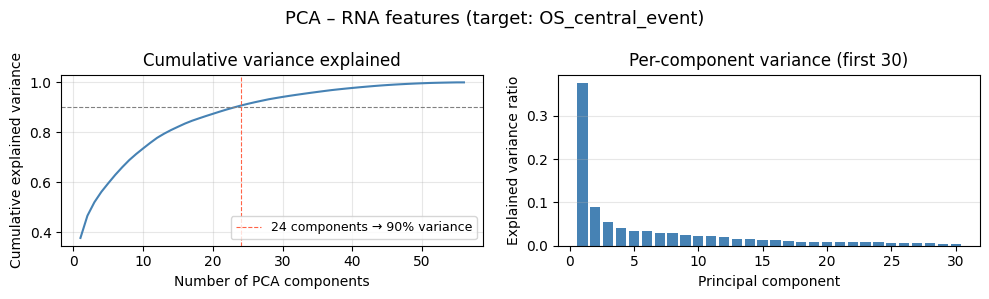

Components to reach 90% variance: 24 / 50986
[RNA → OS_central_event]  n=56  positives=21  features=50986


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

model  fold                             best_params
   LR     1             {'C': 1.0, 'l1_ratio': 1.0}
   LR     2             {'C': 1.0, 'l1_ratio': 0.5}
   LR     3             {'C': 1.0, 'l1_ratio': 0.5}
   RF     1 {'max_depth': 3, 'min_samples_leaf': 3}
   RF     2 {'max_depth': 3, 'min_samples_leaf': 1}
   RF     3 {'max_depth': 5, 'min_samples_leaf': 1}


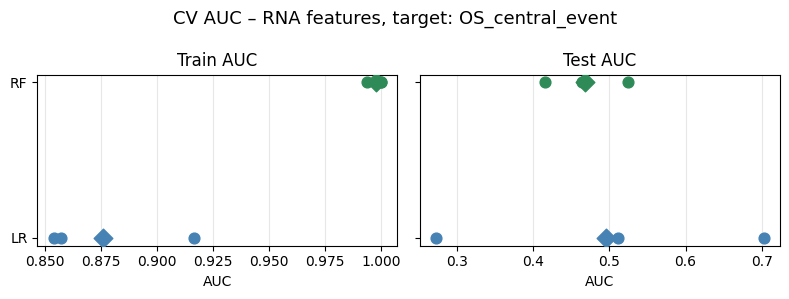

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA → OS_central_event,LR,0.496,0.176,0.533,0.104
1,RNA → OS_central_event,RF,0.468,0.044,0.568,0.142


In [12]:
# === Experiment 2: RNA features only, target = OS_central_event (from clinical) ===
rna_clin = rna_data.merge(
    clinical_data[["SID", "OS_central_event"]], on="SID", how="inner"
)
print(f"Experiment 2 dataset size: {len(rna_clin)}")

X_exp2 = rna_clin[rna_cols].reset_index(drop=True)
y_exp2 = rna_clin["OS_central_event"].reset_index(drop=True)

X_pre2 = build_preprocessor(rna_x_columns).fit_transform(X_exp2[~y_exp2.isna()])
plot_pca_variance(X_pre2, title="PCA – RNA features (target: OS_central_event)")

cv_results2, fold_df2 = run_cv_experiment(
    X_exp2,
    y_exp2,
    rna_x_columns,
    label="RNA → OS_central_event",
    param_grids=PARAM_GRIDS,
)
print(fold_df2[["model", "fold", "best_params"]].to_string(index=False))
plot_cv_results(fold_df2, title="CV AUC – RNA features, target: OS_central_event")
cv_results2

Experiment 3 dataset size: 60


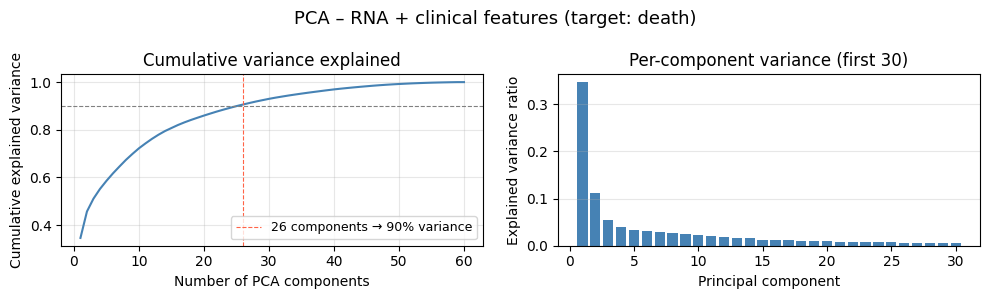

Components to reach 90% variance: 26 / 51012
[RNA+Clinical → death]  n=60  positives=24  features=50997


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

model  fold                             best_params
   LR     1             {'C': 1.0, 'l1_ratio': 0.5}
   LR     2            {'C': 10.0, 'l1_ratio': 0.5}
   LR     3            {'C': 10.0, 'l1_ratio': 0.5}
   RF     1 {'max_depth': 3, 'min_samples_leaf': 1}
   RF     2 {'max_depth': 5, 'min_samples_leaf': 1}
   RF     3 {'max_depth': 3, 'min_samples_leaf': 5}


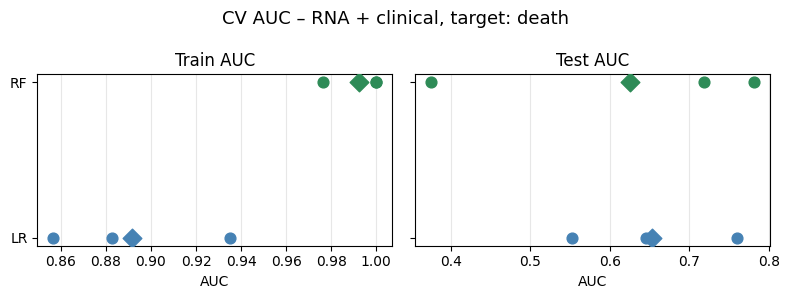

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA+Clinical → death,LR,0.653,0.085,0.617,0.062
1,RNA+Clinical → death,RF,0.625,0.179,0.550,0.071


In [13]:
# === Experiment 3: RNA + clinical features, target = death ===
rna_clin_rad = rna_data.merge(radiomic_death, on="SID", how="inner").merge(
    clinical_data, on="SID", how="inner"
)
print(f"Experiment 3 dataset size: {len(rna_clin_rad)}")

X_exp3 = rna_clin_rad[list(rna_clin_x_columns.keys())].reset_index(drop=True)
y_exp3 = rna_clin_rad["death"].reset_index(drop=True)

X_pre3 = build_preprocessor(rna_clin_x_columns).fit_transform(X_exp3[~y_exp3.isna()])
plot_pca_variance(X_pre3, title="PCA – RNA + clinical features (target: death)")

cv_results3, fold_df3 = run_cv_experiment(
    X_exp3,
    y_exp3,
    rna_clin_x_columns,
    label="RNA+Clinical → death",
    param_grids=PARAM_GRIDS,
)
print(fold_df3[["model", "fold", "best_params"]].to_string(index=False))
plot_cv_results(fold_df3, title="CV AUC – RNA + clinical, target: death")
cv_results3

Experiment 4 dataset size: 60


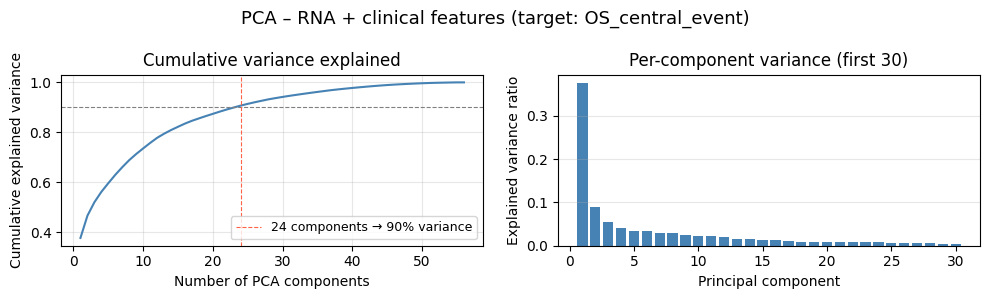

Components to reach 90% variance: 24 / 51012
[RNA+Clinical → OS_central_event]  n=56  positives=21  features=50997


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

model  fold                             best_params
   LR     1             {'C': 1.0, 'l1_ratio': 1.0}
   LR     2             {'C': 1.0, 'l1_ratio': 0.5}
   LR     3             {'C': 1.0, 'l1_ratio': 0.5}
   RF     1 {'max_depth': 3, 'min_samples_leaf': 3}
   RF     2 {'max_depth': 3, 'min_samples_leaf': 1}
   RF     3 {'max_depth': 5, 'min_samples_leaf': 1}


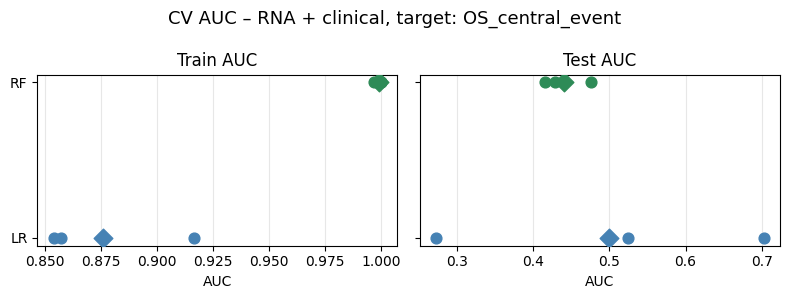

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RNA+Clinical → OS_central_event,LR,0.50,0.176,0.551,0.114
1,RNA+Clinical → OS_central_event,RF,0.44,0.026,0.568,0.129


In [14]:
# === Experiment 4: RNA + clinical features, target = OS_central_event ===
rna_clin_full = rna_data.merge(clinical_data, on="SID", how="inner")
print(f"Experiment 4 dataset size: {len(rna_clin_full)}")

X_exp4 = rna_clin_full[list(rna_clin_x_columns.keys())].reset_index(drop=True)
y_exp4 = rna_clin_full["OS_central_event"].reset_index(drop=True)

X_pre4 = build_preprocessor(rna_clin_x_columns).fit_transform(X_exp4[~y_exp4.isna()])
plot_pca_variance(
    X_pre4, title="PCA – RNA + clinical features (target: OS_central_event)"
)

cv_results4, fold_df4 = run_cv_experiment(
    X_exp4,
    y_exp4,
    rna_clin_x_columns,
    label="RNA+Clinical → OS_central_event",
    param_grids=PARAM_GRIDS,
)
print(fold_df4[["model", "fold", "best_params"]].to_string(index=False))
plot_cv_results(fold_df4, title="CV AUC – RNA + clinical, target: OS_central_event")
cv_results4

                     experiment model  AUC mean  AUC std  Accuracy mean  Accuracy std
                    RNA → death    LR     0.653    0.085          0.617         0.062
                    RNA → death    RF     0.622    0.170          0.567         0.085
         RNA → OS_central_event    LR     0.496    0.176          0.533         0.104
         RNA → OS_central_event    RF     0.468    0.044          0.568         0.142
           RNA+Clinical → death    LR     0.653    0.085          0.617         0.062
           RNA+Clinical → death    RF     0.625    0.179          0.550         0.071
RNA+Clinical → OS_central_event    LR     0.500    0.176          0.551         0.114
RNA+Clinical → OS_central_event    RF     0.440    0.026          0.568         0.129


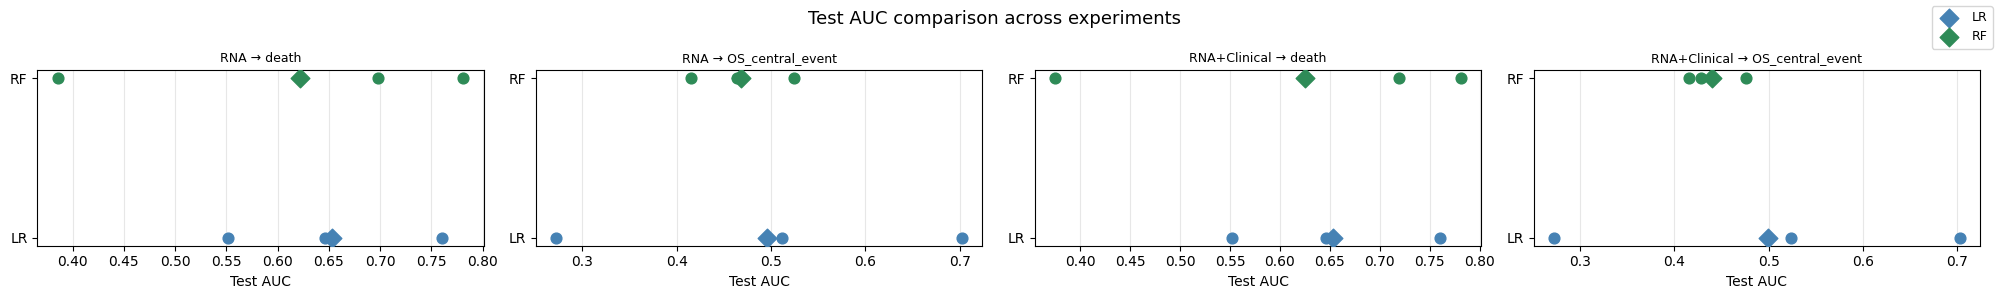

In [15]:
# === Combined comparison across all four experiments ===
all_cv = pd.concat(
    [cv_results1, cv_results2, cv_results3, cv_results4], ignore_index=True
)
all_folds = pd.concat([fold_df1, fold_df2, fold_df3, fold_df4], ignore_index=True)

print(all_cv.to_string(index=False))
plot_experiment_comparison(all_folds)